## Holiday Package Prediciton
### "Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
###  Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.
### Tasks to Solve.
### 1.)To predict which customer is more likely to purchase the newly introduced travel package.
### 2.) Which variables are most significant.
### 3.) Which segment of customers should be targeted more.

In [1]:
## Importing Libraries

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline 

In [3]:
## Loading Data 

In [4]:
Data=pd.read_csv('Travel.csv')

In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [6]:
Data.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

##### we can see we have some columns which have null values which we will later fill using encoding in feature engineering 

In [7]:
## Checking which categorical columns have number of categories and the unique categories 
for col in Data.select_dtypes(include='object').columns:
    print(Data[col].value_counts(dropna=False))

TypeofContact
Self Enquiry       3444
Company Invited    1419
NaN                  25
Name: count, dtype: int64
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64
Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64


## EDA (Exploratory Data Analysis)

The goal of EDA is to understand data distributions, relationships,
and how features influence the target variable (ProdTaken).


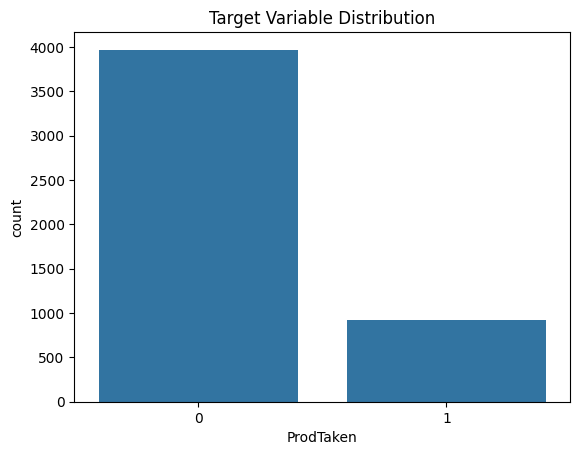

In [8]:
plt.figure()
sns.countplot(x='ProdTaken', data=Data)
plt.title('Target Variable Distribution')
plt.show()


Observation:
The dataset shows moderate class imbalance, making ROC–AUC
and Recall important evaluation metrics.


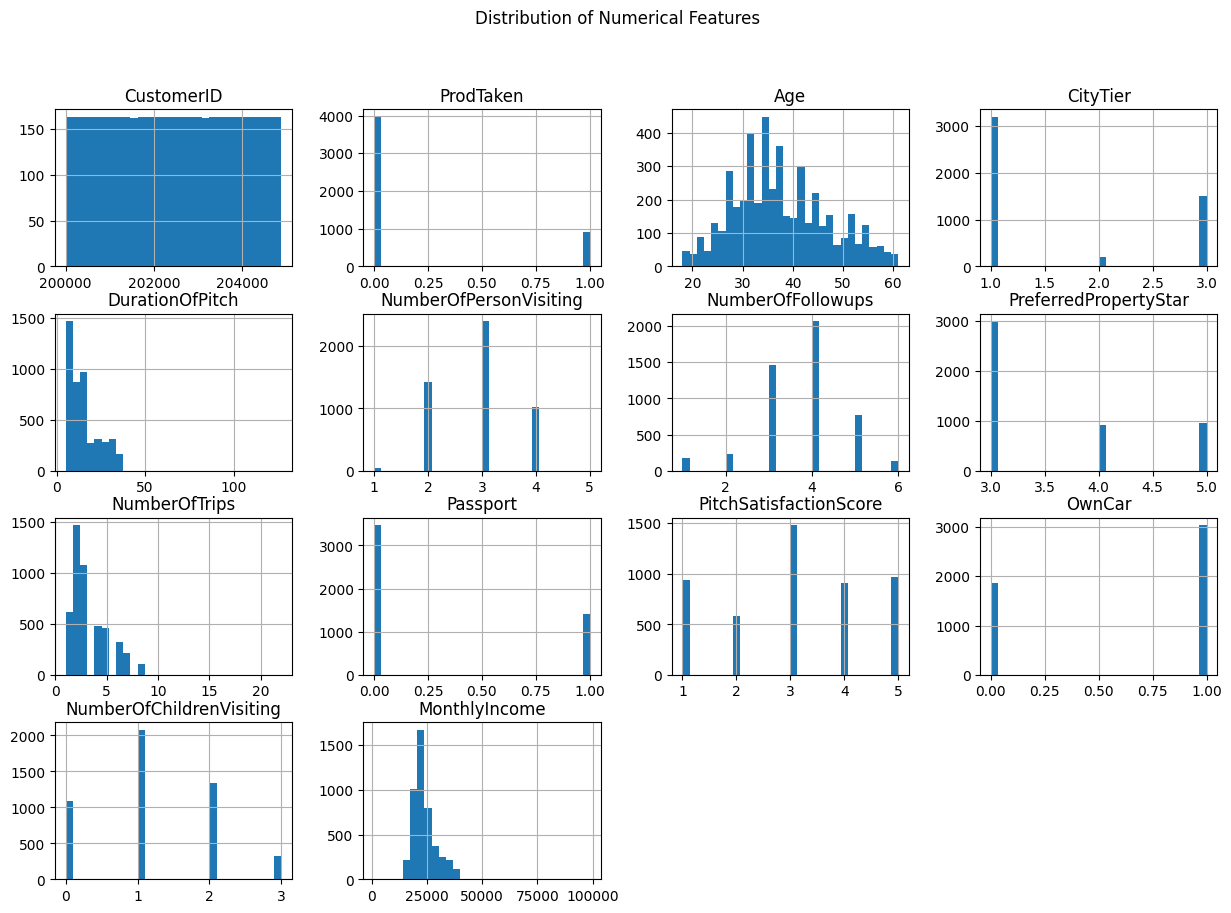

In [9]:
num_cols = Data.select_dtypes(include=['int64','float64']).columns

Data[num_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

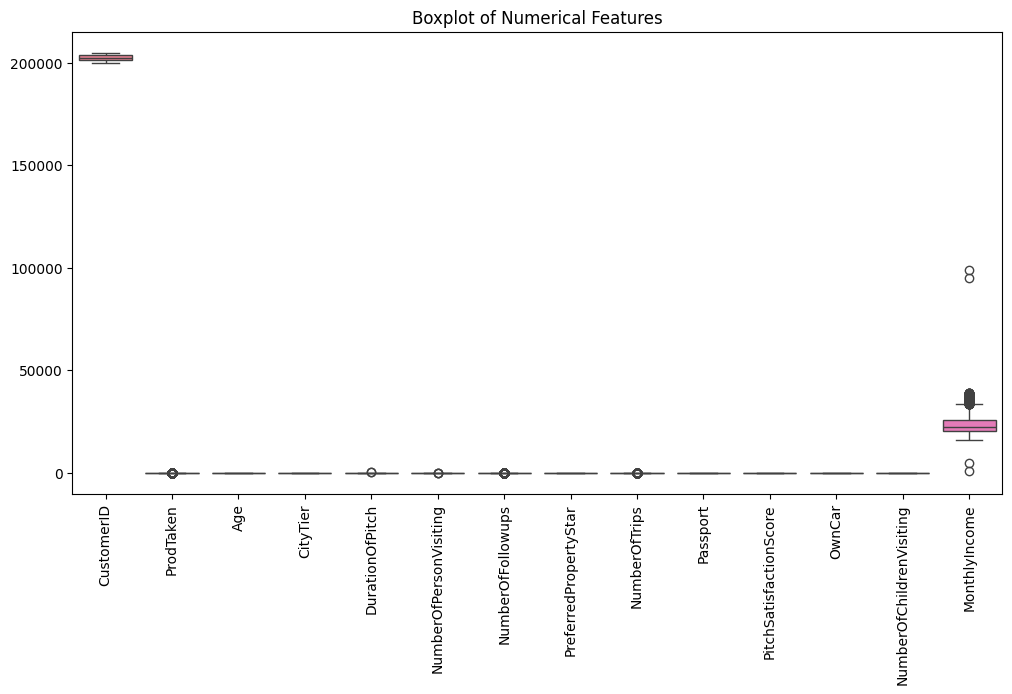

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=Data[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()


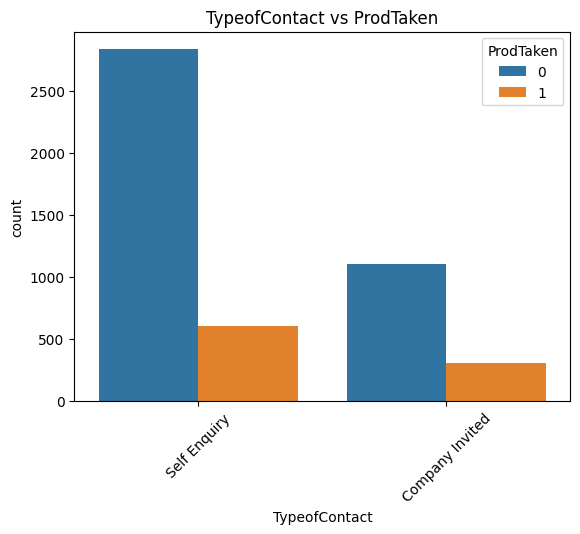

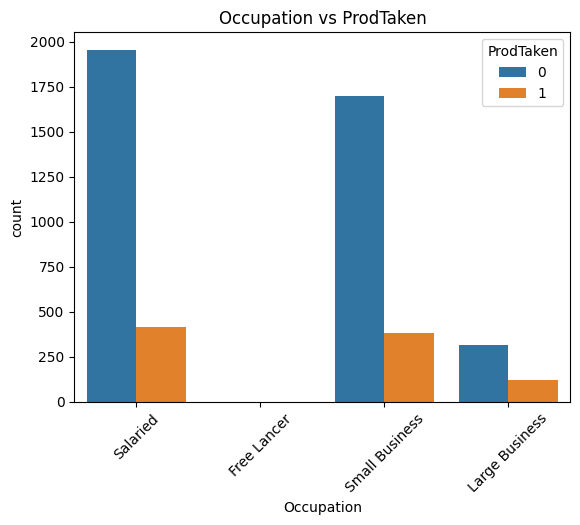

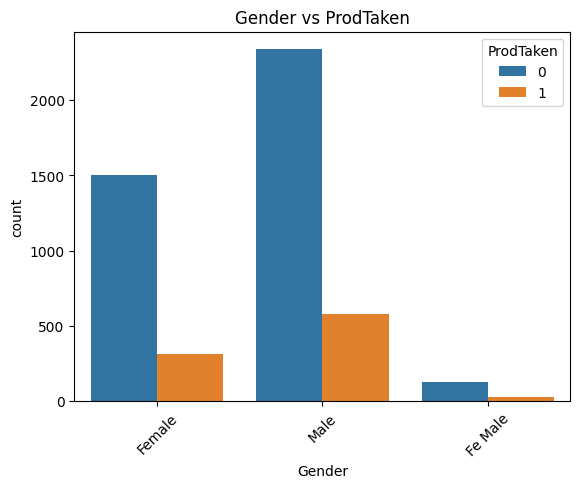

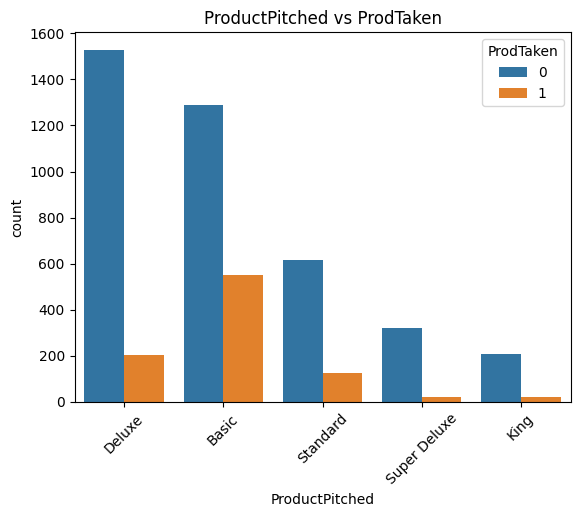

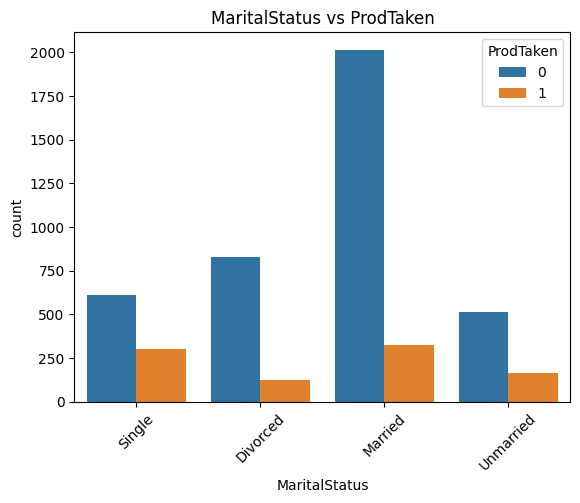

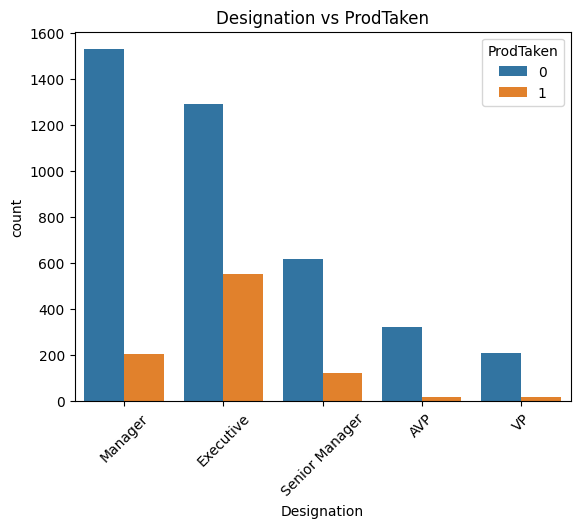

In [11]:
cat_cols = Data.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='ProdTaken', data=Data)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs ProdTaken')
    plt.show()


Certain occupations convert more

TypeOfContact impacts success rate

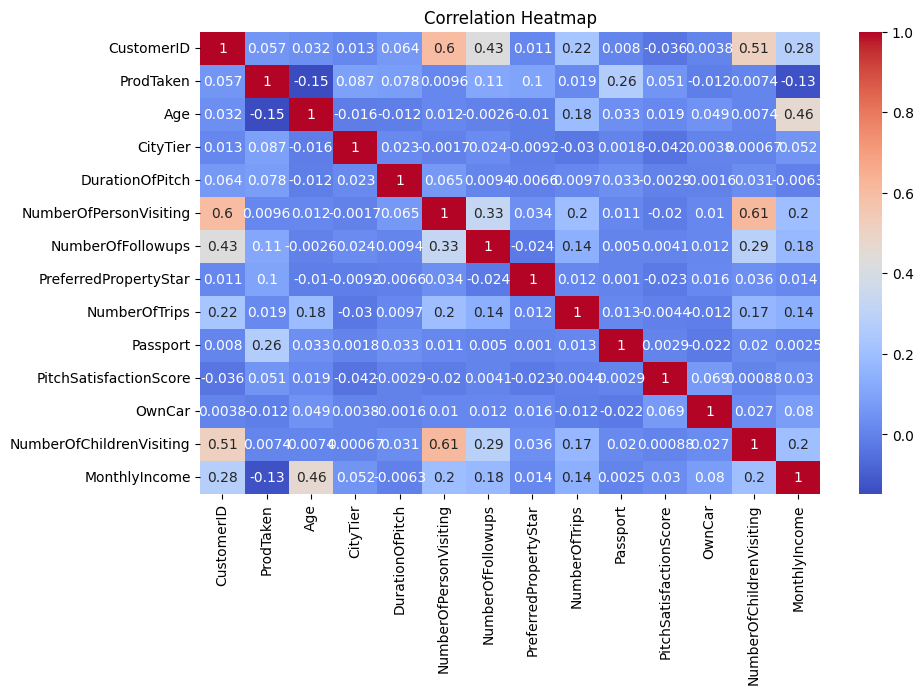

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(Data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


No extremely high correlation

Tree models safe; linear models stable

## Since Gender and Marital Status had same categories with different errors we correct them with their true categories 

In [13]:
Data['Gender']=Data['Gender'].replace('Fe Male','Female')
Data['MaritalStatus']=Data['MaritalStatus'].replace('Unmarried','Single')

# Finding how much values are missing from numerical columns 

In [14]:
features_with_na=[ feature for feature in Data.columns if Data[feature].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(Data[feature].isnull().mean()*100,4),'% Missing Values')


Age 4.6236 % Missing Values
TypeofContact 0.5115 % Missing Values
DurationOfPitch 5.135 % Missing Values
NumberOfFollowups 0.9206 % Missing Values
PreferredPropertyStar 0.5319 % Missing Values
NumberOfTrips 2.8642 % Missing Values
NumberOfChildrenVisiting 1.3502 % Missing Values
MonthlyIncome 4.7668 % Missing Values


In [15]:
# Statistical Analysis for Imputation 
Data[features_with_na].describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing Null values
1. Impute Median value for Age column
2. Impute Mode for Type of Contract
3. Impute Median for Duration of Pitch
4. Impute Mode for NumberofFollowup as it is Discrete feature
5. Impute Mode for PreferredPropertyStar
6. Impute Median for NumberofTrips
7. Impute Mode for NumberOfChildrenVisiting
8. Impute Median for MonthlyIncome

In [16]:
Data['Age'].fillna(Data.Age.median(),inplace=True)
Data['TypeofContact'].fillna(Data.TypeofContact.mode()[0],inplace=True)
Data['DurationOfPitch'].fillna(Data.DurationOfPitch.median(),inplace=True)
Data['NumberOfFollowups'].fillna(Data.NumberOfFollowups.mode()[0],inplace=True)
Data['PreferredPropertyStar'].fillna(Data.PreferredPropertyStar.mode()[0],inplace=True)
Data['NumberOfTrips'].fillna(Data.NumberOfTrips.median(),inplace=True)
Data['NumberOfChildrenVisiting'].fillna(Data.NumberOfChildrenVisiting.mode()[0],inplace=True)
Data['MonthlyIncome'].fillna(Data.MonthlyIncome.median(),inplace=True)

In [17]:
## Now the null values have been imputed 
Data.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

 Now that we have filled null values we can drop our customer id column as it is not needed and then move to Feature engineering 

## FEATURE ENGINEERING 

In [18]:
Data.drop('CustomerID',axis=1,inplace=True)

In [19]:
## creating new Column by combining the Number of personvisiting and number of childeren visiting 
Data['Total Visits']=Data['NumberOfPersonVisiting']+Data['NumberOfChildrenVisiting']

In [20]:
Data.drop(['NumberOfPersonVisiting','NumberOfChildrenVisiting'],axis=1,inplace=True)
Data.head()


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Total Visits
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


### Creating variables for numerical features ,Categorical features ,Discrete , Continous features and finding the length of them 

In [21]:
num_feature=[feature for feature in Data.columns if Data[feature].dtypes !='O']
print('Number of NUmerical Features:',len(num_feature))

Number of NUmerical Features: 12


In [22]:
cat_feature=[feature for feature in Data.columns if Data[feature].dtypes =='O']
print('Number of Categorical Columns:',len(cat_feature))

Number of Categorical Columns: 6


In [23]:
dis_feature=[feature for feature in num_feature if len(Data[feature].unique())<=25]
print('Discrete Feature:',len(dis_feature))

Discrete Feature: 9


In [24]:
con_feature=[feature for feature in num_feature if feature not in dis_feature]
print('Continous Feature :',len(con_feature))

Continous Feature : 3


In [25]:
Data.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Total Visits
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [26]:
X=Data.drop('ProdTaken',axis=1)
Y=Data['ProdTaken']

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.28,stratify=Y,random_state=42)

### Note:
Scaling is essential for Logistic Regression but not required for tree-based models.
However, scaling was applied uniformly for pipeline consistency.


In [28]:
num_column= X.select_dtypes(exclude='object').columns
cat_column=X.select_dtypes(include='object').columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
num_transformer=StandardScaler()
onehot_transformer=OneHotEncoder()

preprocessor= ColumnTransformer(
    [
        ('one hot encoder',onehot_transformer,cat_column),
        ('Standard Scaler',num_transformer,num_column)
    ]
)

In [29]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one hot encoder', ...), ('Standard Scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

In [30]:
X_train=preprocessor.fit_transform(X_train)

In [31]:
X_test=preprocessor.transform(X_test)

In [32]:
pd.DataFrame(X_test)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,-0.714155,0.062689,0.292533,-0.726741,-0.118618,1.566329,-0.789890,-1.289919,-0.481697,-0.056093
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,-0.714155,0.180596,-1.718058,-0.726741,-0.118618,-0.638436,-1.520216,-1.289919,-0.257610,1.363981
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.375659,-0.173125,-0.712763,0.529967,-0.118618,-0.638436,-0.059563,0.775242,-0.226440,-0.766129
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,-0.714155,1.005945,0.292533,-0.726741,-0.666411,1.566329,-0.059563,-1.289919,2.083797,-0.766129
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.465474,-0.291031,-0.712763,-0.726741,-0.666411,1.566329,0.670763,-1.289919,-0.226440,-0.056093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,-0.714155,1.359666,-2.723354,0.529967,-0.666411,-0.638436,-1.520216,0.775242,-1.237394,-0.056093
1365,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,-0.714155,-1.116380,0.292533,0.529967,-0.666411,-0.638436,0.670763,-1.289919,-1.083822,-0.766129
1366,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,-0.714155,1.831293,0.292533,0.529967,0.429174,-0.638436,-0.059563,-1.289919,0.669525,-0.766129
1367,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.465474,-0.173125,0.292533,-0.726741,0.976967,1.566329,1.401089,0.775242,0.349456,0.653944


In [33]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,-0.714155,-0.173125,0.292533,-0.726741,0.429174,-0.638436,1.401089,0.775242,0.075573,-0.766129
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,-0.714155,-0.762659,-0.712763,-0.726741,0.976967,1.566329,-1.520216,-1.289919,2.085888,-0.766129
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.465474,0.534317,0.292533,-0.726741,0.976967,-0.638436,-0.059563,-1.289919,-0.684686,-0.766129
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.465474,-1.116380,0.292533,-0.726741,-0.666411,1.566329,-1.520216,0.775242,-0.276617,-0.056093
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.465474,0.534317,0.292533,-0.726741,0.429174,-0.638436,-0.789890,-1.289919,-0.086932,0.653944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3514,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,-0.714155,-0.055218,-0.712763,-0.726741,-0.666411,1.566329,1.401089,0.775242,-0.421256,0.653944
3515,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,-0.714155,-0.762659,0.292533,-0.726741,0.429174,-0.638436,-0.059563,-1.289919,-1.209075,-0.766129
3516,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.465474,-0.644752,0.292533,-0.726741,-0.666411,1.566329,1.401089,0.775242,1.693404,-0.056093
3517,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.465474,0.652224,-0.712763,1.786675,-1.214204,-0.638436,-1.520216,0.775242,0.912808,0.653944


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve

In [35]:
models={
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'GradientBoostingClassifier':GradientBoostingClassifier(),
    'RandomForestClassifier': RandomForestClassifier()
}
for i in  range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,Y_train)

    # Make predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(Y_train, Y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(Y_train, Y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(Y_train, Y_train_pred) # Calculate Precision
    model_train_recall = recall_score(Y_train, Y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(Y_train, Y_train_pred) # calculate roc 


    # Test set performance
    model_test_accuracy = accuracy_score(Y_test, Y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(Y_test, Y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(Y_test, Y_test_pred) # Calculate Precision
    model_test_recall = recall_score(Y_test, Y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(Y_test, Y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('-'*40)
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*40)
    print('\n')



    


LogisticRegression
Model performance for Training set
- Accuracy: 0.8485
- F1 score: 0.8252
- Precision: 0.7101
- Recall: 0.3293
- Roc Auc Score: 0.6491
----------------------------------------
Model performance for Test set
- Accuracy: 0.8371
- F1 score: 0.8092
- Precision: 0.6606
- Recall: 0.2791
- Roc Auc Score: 0.6229


DecisionTreeClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model performance for Test set
- Accuracy: 0.8860
- F1 score: 0.8864
- Precision: 0.6947
- Recall: 0.7054
- Roc Auc Score: 0.8167


GradientBoostingClassifier
Model performance for Training set
- Accuracy: 0.8872
- F1 score: 0.8749
- Precision: 0.8442
- Recall: 0.4909
- Roc Auc Score: 0.7350
----------------------------------------
Model performance for Test set
- Accuracy: 0.8576
- F1 score: 0.8394
- Precision: 0.7299
- Recall: 0.3876
- Roc Auc Score: 0.6771


RandomFore

In [36]:
ran_forest_pm={
    'n_estimators':[100,200,500,0,1000],
    'max_depth':[20,30,50,40],
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_features':['sqrt', 'log2',None],
    'min_samples_split':[2,8,10,20]
}
log_params={
    'penalty':['l1', 'l2', 'elasticnet', None],
    'C':[1,4,5,2],
    'solver':['lbfgs','liblinear', 'newton-cg', 'newton-cholesky','sag','saga']
}
Dt_params={
    'criterion':['gini', 'entropy','log_loss'],
    'splitter':['best', 'random'],
    'max_features':['sqrt','log2']
}

In [37]:
modelcv=[
         ('Random Forest',RandomForestClassifier(),ran_forest_pm),
         ('Logistic Regression',LogisticRegression(),log_params),
         ('Decision Tree',DecisionTreeClassifier(),Dt_params)
]

In [38]:
modelcv

[('Random Forest',
  RandomForestClassifier(),
  {'n_estimators': [100, 200, 500, 0, 1000],
   'max_depth': [20, 30, 50, 40],
   'criterion': ['gini', 'entropy', 'log_loss'],
   'max_features': ['sqrt', 'log2', None],
   'min_samples_split': [2, 8, 10, 20]}),
 ('Logistic Regression',
  LogisticRegression(),
  {'penalty': ['l1', 'l2', 'elasticnet', None],
   'C': [1, 4, 5, 2],
   'solver': ['lbfgs',
    'liblinear',
    'newton-cg',
    'newton-cholesky',
    'sag',
    'saga']}),
 ('Decision Tree',
  DecisionTreeClassifier(),
  {'criterion': ['gini', 'entropy', 'log_loss'],
   'splitter': ['best', 'random'],
   'max_features': ['sqrt', 'log2']})]

In [39]:
from sklearn.model_selection import RandomizedSearchCV
model_param = {}
for name, model, params in modelcv:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, Y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"------ Best Params for {model_name}------")
    print(model_param[model_name])


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
------ Best Params for Random Forest------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': None, 'max_depth': 50, 'criterion': 'entropy'}
------ Best Params for Logistic Regression------
{'solver': 'saga', 'penalty': 'l1', 'C': 1}
------ Best Params for Decision Tree------
{'splitter': 'random', 'max_features': 'sqrt', 'criterion': 'entropy'}


In [40]:
models={
    'LogisticRegression': LogisticRegression(solver='saga',penalty='l1',C=1),
    'DecisionTreeClassifier': DecisionTreeClassifier(splitter='random',max_features='sqrt',criterion='log_loss'),
    'RandomForestClassifier': RandomForestClassifier(n_estimators= 1000, min_samples_split=2,max_features=None,max_depth=20,criterion='entropy')
}
for i in  range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,Y_train)

    # Make predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(Y_train, Y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(Y_train, Y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(Y_train, Y_train_pred) # Calculate Precision
    model_train_recall = recall_score(Y_train, Y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(Y_train, Y_train_pred) # calculate roc 


    # Test set performance
    model_test_accuracy = accuracy_score(Y_test, Y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(Y_test, Y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(Y_test, Y_test_pred) # Calculate Precision
    model_test_recall = recall_score(Y_test, Y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(Y_test, Y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('-'*40)
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*40)
    print('\n')

LogisticRegression
Model performance for Training set
- Accuracy: 0.8485
- F1 score: 0.8248
- Precision: 0.7129
- Recall: 0.3263
- Roc Auc Score: 0.6479
----------------------------------------
Model performance for Test set
- Accuracy: 0.8371
- F1 score: 0.8092
- Precision: 0.6606
- Recall: 0.2791
- Roc Auc Score: 0.6229


DecisionTreeClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model performance for Test set
- Accuracy: 0.8809
- F1 score: 0.8815
- Precision: 0.6792
- Recall: 0.6977
- Roc Auc Score: 0.8106


RandomForestClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model performance for Test set
- Accuracy: 0.9321
- F1 score: 0.9287
- Precision: 0.9104
- Recall: 0.7093
- Roc Auc Score: 0.8466




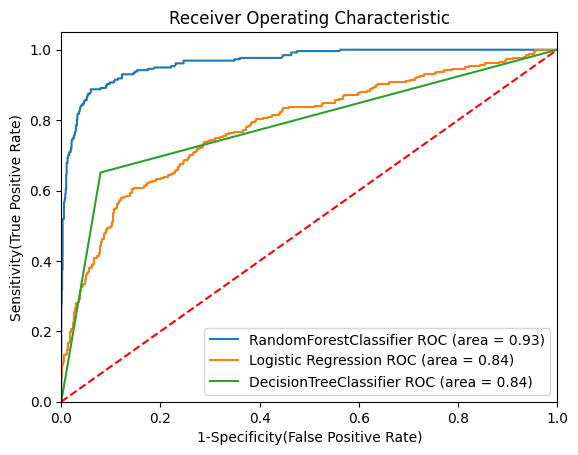

In [41]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.plot()
auc_model=[
    {
        'label':'RandomForestClassifier',
        'model': RandomForestClassifier(n_estimators= 1000, min_samples_split=2,max_features=None,max_depth=20,criterion='entropy'),
        'auc' : 0.9335
    },
    {
        'label':'Logistic Regression',
        'model': LogisticRegression(solver='saga',penalty='l1',C=1),
        'auc':  0.8437
    },
    {
        'label':'DecisionTreeClassifier',
        'model':DecisionTreeClassifier(splitter='random',max_features='sqrt',criterion='log_loss') ,
        'auc': 0.8371
    }
]


for j in auc_model:
    model=j['model']
    model.fit(X_train,Y_train)
    fpr,tpr,thresholds=roc_curve(Y_test,model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (j['label'],j['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 

In [42]:
feature_names = preprocessor.get_feature_names_out()
clean_features = []

for f in feature_names:
    f = f.replace('StandardScaler__', '')
    f = f.replace('one hot encoder__', '')
    clean_features.append(f)
imp_df = pd.DataFrame({
    'Feature': clean_features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)


In [43]:
imp_df

,Feature,Importance
27,Standard Scaler__Passport,0.090763
23,Standard Scaler__DurationOfPitch,0.090090
21,Standard Scaler__Age,0.085503
28,Standard Scaler__PitchSatisfactionScore,0.072933
26,Standard Scaler__NumberOfTrips,0.055584
8,ProductPitched_Basic,0.054701
30,Standard Scaler__MonthlyIncome,0.053507
25,Standard Scaler__PreferredPropertyStar,0.051305
31,Standard Scaler__Total Visits,0.046504
22,Standard Scaler__CityTier,0.041920


### Feature Importance Interpretation:
Random Forest identifies customer income, age, pitch duration,
and travel-related attributes as the most influential factors.
Categorical features such as marital status and occupation
also play a significant role in predicting package purchase.


### Recommendation:
### 1.)Random Forest is selected due to highest ROC-AUC (0.94).
### 2.)The model should be used to prioritize customer outreach,improving conversion while reducing marketing cost.
